## 載入套件

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error


## 載入資料與切分訓練集

In [134]:
# ==========================================
# 0. Load data
# ==========================================
df = pd.read_csv("../data/raw/DCOILWTICO.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])

# 價格轉 numeric，並將非數字自動轉為 NaN
df["DCOILWTICO"] = pd.to_numeric(df["DCOILWTICO"], errors='coerce')

# 過濾 missing prices
price = (
    df.loc[
        df["DCOILWTICO"].notna(),
        ["observation_date", "DCOILWTICO"]
    ]
    .set_index("observation_date")["DCOILWTICO"]
)

# 計算日報酬率 Return
return_series = price.pct_change().dropna()

# 依日期（split_date）切分訓練集和測試集
split_date = "2023-01-01"
train_data = return_series[return_series.index < split_date]
test_data = return_series[return_series.index >= split_date]

print("Training period:", train_data.index.min(), "to", train_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())
print("\nTraining observations:", len(train_data))
print("Test observations:", len(test_data))

#因為Return太小所以乘上100
train_scaled = train_data * 100
test_scaled = test_data * 100

check_split = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Start Date": [train_data.index.min(), test_data.index.min()],
    "End Date": [train_data.index.max(), test_data.index.max()],
    "Observations": [len(train_data), len(test_data)]
})

check_split


Training period: 1986-01-03 00:00:00 to 2022-12-30 00:00:00
Test period: 2023-01-03 00:00:00 to 2026-08-18 00:00:00

Training observations: 9322
Test observations: 903


,Dataset,Start Date,End Date,Observations
0,Train,1986-01-03,2022-12-30,9322
1,Test,2023-01-03,2026-08-18,903


## 擬合ARIMA(p,0,q)、選定候選模型
檢定是否有ARCH 效應，若有則考慮加入GARCH

In [ ]:
# ==========================================================
# 1：設定 ARIMA 候選模型
# ==========================================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

# 報酬率已通過平穩性檢定，因此固定 d = 0
# 比較 p、q = 0～3 的所有組合
model_specs = {}

for p in range(11):
    for q in range(11):
        model_specs[f"ARIMA({p},0,{q})"] = (p, q)


# ==========================================================
# 2：建立 ARIMA 模型 + Ljung-Box 殘差診斷
# ==========================================================

arima_results = {}

for name, (p, q) in model_specs.items():

    # 建立 ARIMA 模型
    model = ARIMA(
        train_scaled,
        order=(p, 0, q)
    )

    # 模型配適
    result = model.fit()

    # 取得 ARIMA residual
    residual = result.resid

    # ------------------------------------------------------
    # Ljung-Box Test
    # ------------------------------------------------------
    
    # H0：Lag 1～10 的自相關係數皆為 0
    # p-value > 0.05 → 沒有足夠證據認為存在自相關
    # p-value < 0.05 → 殘差仍存在顯著自相關

    lb_test = acorr_ljungbox(
        residual,
        lags=[10],
        return_df=True
    )

    lb_stat = lb_test["lb_stat"].iloc[0]
    lb_p = lb_test["lb_pvalue"].iloc[0]


    # 儲存結果
    arima_results[name] = {
        "AIC": result.aic,
        "BIC": result.bic,
        "Log-Likelihood": result.llf,
        "LB(10) Statistic": lb_stat,
        "LB(10) P-value": lb_p
    }


# ==========================================================
# 3：建立模型比較表
# ==========================================================

arima_comparison = pd.DataFrame(arima_results).T


# ==========================================================
# 4：增加 Ljung-Box 診斷結果
# ==========================================================

arima_comparison["LB(10) Result"] = arima_comparison[
    "LB(10) P-value"
].apply(
    lambda p: "Pass" if p > 0.05 else "Fail"
)


# ==========================================================
# 5：按照 AIC 排序
# ==========================================================

arima_final_comparison = (
    arima_comparison
    .sort_values("AIC")
)


# ==========================================================
# 6：顯示結果
# ==========================================================

arima_final_comparison

/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, bu

,AIC,BIC,Log-Likelihood,LB(10) Statistic,LB(10) P-value,LB(10) Result
"ARIMA(6,0,8)",53249.144210,53363.386330,-26608.572105,9.810011,4.573170e-01,Pass
"ARIMA(6,0,9)",53253.028209,53374.410461,-26609.514104,9.529070,4.827333e-01,Pass
"ARIMA(8,0,6)",53259.465442,53373.707561,-26613.732721,8.775856,5.534998e-01,Pass
"ARIMA(8,0,9)",53259.724354,53395.386871,-26610.862177,18.317250,4.984214e-02,Fail
"ARIMA(9,0,8)",53260.749684,53396.412201,-26611.374842,20.186300,2.753904e-02,Fail
...,...,...,...,...,...,...
"ARIMA(0,0,2)",53431.366898,53459.927428,-26711.683449,93.889330,9.038685e-16,Fail
"ARIMA(1,0,1)",53448.707121,53477.267651,-26720.353561,114.791037,5.748190e-20,Fail
"ARIMA(0,0,1)",53476.404340,53497.824738,-26735.202170,150.182204,3.419250e-27,Fail
"ARIMA(1,0,0)",53556.983180,53578.403578,-26775.491590,247.046014,2.267758e-47,Fail


In [135]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import pandas as pd

# =========================
# 1. ARIMA 候選模型
# =========================

arima_candidates = {
    "ARIMA(2,0,3)": (2, 0, 3),
    "ARIMA(6,0,8)": (6, 0, 8),
    "ARIMA(6,0,9)": (6, 0, 9),
    "ARIMA(8,0,6)": (8, 0, 6)
}

arima_fitted = {}
arima_residuals = {}

arima_results = []

for name, order in arima_candidates.items():

    model = ARIMA(
        train_scaled,
        order=order
    )

    result = model.fit()

    # 儲存模型
    arima_fitted[name] = result

    # 儲存各自 residual
    arima_residuals[name] = result.resid

    # =========================
    # 2. Ljung-Box Test
    # 對 residual
    # H0：無自我相關
    # =========================

    lb_test = acorr_ljungbox(
        result.resid,
        lags=[10],
        return_df=True
    )

    # =========================
    # 3. ARCH LM Test
    # H0：無 ARCH effect
    # =========================

    arch_stat, arch_p, _, _ = het_arch(
        result.resid
    )

    # =========================
    # 4. Ljung-Box Q² Test
    # 對「平方 residual」
    # H0：平方 residual 無自我相關
    # =========================

    q2_test = acorr_ljungbox(
        result.resid ** 2,
        lags=[10],
        return_df=True
    )

    # =========================
    # 5. 儲存結果
    # =========================

    arima_results.append({
        "Model": name,
        "AIC": result.aic,
        "BIC": result.bic,
        "Log-Likelihood": result.llf,

        "LB(10) Statistic": lb_test["lb_stat"].iloc[0],
        "LB(10) P-value": lb_test["lb_pvalue"].iloc[0],

        "ARCH LM Statistic": arch_stat,
        "ARCH LM P-value": arch_p,

        "Q²(10) Statistic": q2_test["lb_stat"].iloc[0],
        "Q²(10) P-value": q2_test["lb_pvalue"].iloc[0]
    })

# =========================
# 6. ARIMA 比較表
# =========================

arima_comparison = pd.DataFrame(arima_results)

arima_comparison = arima_comparison.sort_values("AIC")

arima_comparison

/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain 

,Model,AIC,BIC,Log-Likelihood,LB(10) Statistic,LB(10) P-value,ARCH LM Statistic,ARCH LM P-value,Q²(10) Statistic,Q²(10) P-value
1,"ARIMA(6,0,8)",53249.144210,53363.386330,-26608.572105,9.810011,0.457317,23.956308,0.007717,24.934994,0.005470
2,"ARIMA(6,0,9)",53253.028209,53374.410461,-26609.514104,9.529070,0.482733,23.840199,0.008036,24.826434,0.005684
3,"ARIMA(8,0,6)",53259.465442,53373.707561,-26613.732721,8.775856,0.553500,24.235571,0.006999,25.326705,0.004759
0,"ARIMA(2,0,3)",53381.001264,53430.982191,-26683.500632,40.997466,0.000011,23.021109,0.010669,23.999994,0.007600


## 擬合GARCH(p,q)、選定候選模型

In [ ]:
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# =========================
# 2. GARCH 候選模型
# =========================

garch_candidates = {
    "GARCH(1,1)": (1, 1),
    "GARCH(1,2)": (1, 2),
    "GARCH(2,1)": (2, 1),
    "GARCH(2,2)": (2, 2)
}

garch_results = []

for arima_name, residual in arima_residuals.items():

    for garch_name, (p, q) in garch_candidates.items():

        model = arch_model(
            residual,
            mean="Zero",
            vol="GARCH",
            p=p,
            q=q,
            dist="normal"
        )

        result = model.fit(disp="off")

        # =========================
        # Standardized residual
        # =========================

        std_resid = result.std_resid.dropna()

        # =========================
        # Ljung-Box Q(10)
        # =========================

        lb_test = acorr_ljungbox(
            std_resid,
            lags=[10],
            return_df=True
        )

        # =========================
        # Ljung-Box Q²(10)
        # =========================

        q2_test = acorr_ljungbox(
            std_resid ** 2,
            lags=[10],
            return_df=True
        )

        # =========================
        # Engle's ARCH LM Test
        # =========================

        arch_stat, arch_p, _, _ = het_arch(std_resid)

        # =========================
        # 儲存結果
        # =========================

        garch_results.append({
            "ARIMA": arima_name,
            "GARCH": garch_name,
            "AIC": result.aic,
            "BIC": result.bic,
            "Log-Likelihood": result.loglikelihood,

            # Ljung-Box Q(10)
            "LB Q(10) Statistic": lb_test["lb_stat"].iloc[0],
            "LB Q(10) P-value": lb_test["lb_pvalue"].iloc[0],

            # Engle's LM Test
            "ARCH LM Statistic": arch_stat,
            "ARCH LM P-value": arch_p,

            # Ljung-Box Q²(10)
            "LB Q²(10) Statistic": q2_test["lb_stat"].iloc[0],
            "LB Q²(10) P-value": q2_test["lb_pvalue"].iloc[0]
        })

# =========================
# 整理結果
# =========================

garch_comparison = pd.DataFrame(garch_results)

garch_comparison = garch_comparison.sort_values("AIC")

garch_comparison

/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
/Users/peilun/Desktop/data_project/.venv/l

,ARIMA,GARCH,AIC,BIC,Log-Likelihood,LB Q(10) Statistic,LB Q(10) P-value,ARCH LM Statistic,ARCH LM P-value,LB Q²(10) Statistic,LB Q²(10) P-value
1,"ARIMA(2,0,3)","GARCH(1,2)",41220.534841,41256.235504,-20605.267421,330.913003,4.448781e-65,0.810982,0.999935,0.797855,0.999940
0,"ARIMA(2,0,3)","GARCH(1,1)",41222.050351,41250.610881,-20607.025175,336.972252,2.311118e-66,0.808556,0.999936,0.796710,0.999940
3,"ARIMA(2,0,3)","GARCH(2,2)",41222.534841,41265.375636,-20605.267421,330.915019,4.444405e-65,0.810970,0.999935,0.797843,0.999940
2,"ARIMA(2,0,3)","GARCH(2,1)",41224.050351,41259.751013,-20607.025175,336.970169,2.313469e-66,0.808584,0.999936,0.796738,0.999940
13,"ARIMA(8,0,6)","GARCH(1,2)",41409.701165,41445.401828,-20699.850583,380.769723,1.159834e-75,0.861759,0.999913,0.849399,0.999919
12,"ARIMA(8,0,6)","GARCH(1,1)",41411.627525,41440.188055,-20701.813763,387.576445,4.139549e-77,0.876459,0.999906,0.865727,0.999912
15,"ARIMA(8,0,6)","GARCH(2,2)",41411.701165,41454.541960,-20699.850583,380.770625,1.159322e-75,0.861768,0.999913,0.849408,0.999919
14,"ARIMA(8,0,6)","GARCH(2,1)",41413.627525,41449.328188,-20701.813763,387.575769,4.140920e-77,0.876428,0.999906,0.865697,0.999912
9,"ARIMA(6,0,9)","GARCH(1,2)",41416.687243,41452.387906,-20703.343622,383.175432,3.571791e-76,0.927807,0.999878,0.913886,0.999886
8,"ARIMA(6,0,9)","GARCH(1,1)",41418.621020,41447.181550,-20705.310510,390.323535,1.078042e-77,0.946690,0.999866,0.934592,0.999874


## 比較GARCH 模型的 innovation distribution （normal,student t）

In [140]:
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import pandas as pd

# ============================================================
# 1. 設定候選 ARIMA 模型
# ============================================================

arima_candidates = {
    "ARIMA(2,0,3)": (2, 0, 3),
    "ARIMA(6,0,8)": (6, 0, 8),
    "ARIMA(6,0,9)": (6, 0, 9),
    "ARIMA(8,0,6)": (8, 0, 6)
}

# ============================================================
# 2. 設定候選 GARCH 模型
# ============================================================

garch_candidates = {
    "GARCH(1,1)": (1, 1),
    "GARCH(1,2)": (1, 2),
    "GARCH(2,1)": (2, 1),
    "GARCH(2,2)": (2, 2)
}

# ============================================================
# 3. 設定分配
# ============================================================

distributions = {
    "Normal": "normal",
    "Student-t": "t"
}

# ============================================================
# 4. 儲存結果
# ============================================================

garch_results = []

# ============================================================
# 5. 跑所有候選組合
# ============================================================

for arima_name in arima_candidates:

    residual = arima_residuals[arima_name]

    for garch_name, (p, q) in garch_candidates.items():

        for dist_name, dist in distributions.items():

            model = arch_model(
                residual,
                mean="Zero",
                vol="GARCH",
                p=p,
                q=q,
                dist=dist
            )

            result = model.fit(disp="off")

            # ====================================================
            # Standardized residual
            # ====================================================

            std_resid = result.std_resid.dropna()

            # ====================================================
            # Ljung-Box Q(10)
            # ====================================================

            lb_test = acorr_ljungbox(
                std_resid,
                lags=[10],
                return_df=True
            )

            # ====================================================
            # Ljung-Box Q²(10)
            # ====================================================

            q2_test = acorr_ljungbox(
                std_resid ** 2,
                lags=[10],
                return_df=True
            )

            # ====================================================
            # Engle's ARCH LM Test
            # ====================================================

            arch_stat, arch_p, _, _ = het_arch(std_resid)

            # ====================================================
            # 儲存結果
            # ====================================================

            garch_results.append({
                "ARIMA": arima_name,
                "GARCH": garch_name,
                "Distribution": dist_name,

                "AIC": result.aic,
                "BIC": result.bic,
                "Log-Likelihood": result.loglikelihood,

                # Ljung-Box Q(10)
                "LB Q(10) Statistic": lb_test["lb_stat"].iloc[0],
                "LB Q(10) P-value": lb_test["lb_pvalue"].iloc[0],

                # Engle's ARCH LM
                "ARCH LM Statistic": arch_stat,
                "ARCH LM P-value": arch_p,

                # Ljung-Box Q²(10)
                "LB Q²(10) Statistic": q2_test["lb_stat"].iloc[0],
                "LB Q²(10) P-value": q2_test["lb_pvalue"].iloc[0]
            })


# ============================================================
# 6. 整理結果
# ============================================================

garch_comparison = pd.DataFrame(garch_results)

garch_comparison = garch_comparison.sort_values("AIC")

garch_comparison

/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
/Users/peilun/Desktop/data_project/.venv/l

,ARIMA,GARCH,Distribution,AIC,BIC,Log-Likelihood,LB Q(10) Statistic,LB Q(10) P-value,ARCH LM Statistic,ARCH LM P-value,LB Q²(10) Statistic,LB Q²(10) P-value
3,"ARIMA(2,0,3)","GARCH(1,2)",Student-t,41220.534841,41256.235504,-20605.267421,330.913003,4.448781e-65,0.810982,0.999935,0.797855,0.999940
1,"ARIMA(2,0,3)","GARCH(1,1)",Student-t,41222.050351,41250.610881,-20607.025175,336.972252,2.311118e-66,0.808556,0.999936,0.796710,0.999940
7,"ARIMA(2,0,3)","GARCH(2,2)",Student-t,41222.534841,41265.375636,-20605.267421,330.915019,4.444405e-65,0.810970,0.999935,0.797843,0.999940
5,"ARIMA(2,0,3)","GARCH(2,1)",Student-t,41224.050351,41259.751013,-20607.025175,336.970169,2.313469e-66,0.808584,0.999936,0.796738,0.999940
27,"ARIMA(8,0,6)","GARCH(1,2)",Student-t,41409.701165,41445.401828,-20699.850583,380.769723,1.159834e-75,0.861759,0.999913,0.849399,0.999919
25,"ARIMA(8,0,6)","GARCH(1,1)",Student-t,41411.627525,41440.188055,-20701.813763,387.576445,4.139549e-77,0.876459,0.999906,0.865727,0.999912
31,"ARIMA(8,0,6)","GARCH(2,2)",Student-t,41411.701165,41454.541960,-20699.850583,380.770625,1.159322e-75,0.861768,0.999913,0.849408,0.999919
29,"ARIMA(8,0,6)","GARCH(2,1)",Student-t,41413.627525,41449.328188,-20701.813763,387.575769,4.140920e-77,0.876428,0.999906,0.865697,0.999912
19,"ARIMA(6,0,9)","GARCH(1,2)",Student-t,41416.687243,41452.387906,-20703.343622,383.175432,3.571791e-76,0.927807,0.999878,0.913886,0.999886
17,"ARIMA(6,0,9)","GARCH(1,1)",Student-t,41418.621020,41447.181550,-20705.310510,390.323535,1.078042e-77,0.946690,0.999866,0.934592,0.999874


## 看個別模型挑選出的模型參數
設定要看哪個模型

In [176]:
# ============================================================
# 設定要查看的模型
# ============================================================

arima_name = "ARIMA(8,0,6)"
garch_name = "GARCH(1,1)"
distribution = "t"

In [177]:
# ============================================================
# ARIMA Summary
# ============================================================

arima_result = arima_fitted[arima_name]

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:             DCOILWTICO   No. Observations:                 9322
Model:                 ARIMA(8, 0, 6)   Log Likelihood              -26613.733
Date:                Fri, 11 Sep 2026   AIC                          53259.465
Time:                        19:13:45   BIC                          53373.708
Sample:                             0   HQIC                         53298.271
                               - 9322                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0072      0.063      0.113      0.910      -0.117       0.131
ar.L1          0.4582      0.130      3.535      0.000       0.204       0.712
ar.L2         -0.3169      0.066     -4.786      0.0

In [178]:
# ============================================================
# GARCH Summary
# ============================================================

residual = arima_residuals[arima_name]

p, q = garch_candidates[garch_name]

garch_model = arch_model(
    residual,
    mean="Zero",
    vol="GARCH",
    p=p,
    q=q,
    dist=distribution
)

garch_result = garch_model.fit(disp="off")

print(garch_result.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -20701.8
Distribution:      Standardized Student's t   AIC:                           41411.6
Method:                  Maximum Likelihood   BIC:                           41440.2
                                              No. Observations:                 9322
Date:                      Fri, Sep 11 2026   Df Residuals:                     9322
Time:                              19:13:56   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

In [148]:
# ============================================================
# ARIMA Parameters
# ============================================================

print("=== ARIMA Parameters ===")
print(arima_result.params)


# ============================================================
# GARCH Parameters
# ============================================================

print("\n=== GARCH Parameters ===")
print(garch_result.params)

=== ARIMA Parameters ===
const      0.007162
ar.L1      0.458151
ar.L2     -0.316858
ar.L3      1.115969
ar.L4     -0.401936
ar.L5      0.364433
ar.L6     -0.522313
ar.L7      0.022959
ar.L8     -0.056607
ma.L1     -0.253106
ma.L2      0.143734
ma.L3     -1.081296
ma.L4      0.208904
ma.L5     -0.212156
ma.L6      0.502342
sigma2    17.733877
dtype: float64

=== GARCH Parameters ===
omega       0.170730
alpha[1]    0.143859
beta[1]     0.634734
beta[2]     0.200978
nu          6.350925
Name: params, dtype: float64


## volatility forecast



In [170]:
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. 設定要比較的完整模型
# =========================================================
models = [
#     {
#         "name": "ARIMA(2,0,3)-GARCH(1,2)-Student-t",
#         "arima": (2, 0, 3),
#         "garch": (1, 2),
#         "dist": "t"
#     },
#    {
#        "name": "ARIMA(2,0,3)-GARCH(1,1)-Student-t",
#        "arima": (2, 0, 3),
#        "garch": (1, 1),
#        "dist": "t"
#    },
#    {
#        "name": "ARIMA(2,0,3)-GARCH(2,2)-Student-t",
#        "arima": (2, 0, 3),
#        "garch": (2, 2),
#        "dist": "t"
#    },
#    {
#        "name": "ARIMA(2,0,3)-GARCH(2,1)-Student-t",
#        "arima": (2, 0, 3),
#        "garch": (2, 1),
#        "dist": "t"
#    }
#     {
#         "name": "ARIMA(8,0,6)-GARCH(1,2)-Student-t",
#         "arima": (8, 0, 6),
#         "garch": (1, 2),
#         "dist": "t"
#     }
     {
         "name": "ARIMA(8,0,6)-GARCH(1,1)-Student-t",
         "arima": (8, 0, 6),
         "garch": (1, 1),
         "dist": "t"
     }
]

# =========================================================
# 2. 準備 expanding-window 資料
# =========================================================

all_data = pd.concat([train_scaled, test_scaled])

train_len = len(train_scaled)


# =========================================================
# 3. 儲存結果
# =========================================================

forecast_results = []
forecast_series = {}


# =========================================================
# 4. 逐一跑模型
# =========================================================

for model_info in models:

    model_name = model_info["name"]
    arima_order = model_info["arima"]
    garch_p, garch_q = model_info["garch"]
    distribution = model_info["dist"]

    print(f"Running: {model_name}")

    forecasts = []

    # -----------------------------------------------------
    # Expanding-window one-step-ahead forecast
    # -----------------------------------------------------

    for i in range(len(test_scaled)):

        # 目前時間點以前的所有資料
        current_data = all_data.iloc[:train_len + i]

        # =========================
        # ARIMA
        # =========================

        arima_model = ARIMA(
            current_data,
            order=arima_order
        )

        arima_result = arima_model.fit()

        # ARIMA residual
        arima_resid = arima_result.resid

        # =========================
        # GARCH
        # =========================

        garch_model = arch_model(
            arima_resid,
            mean="Zero",
            vol="GARCH",
            p=garch_p,
            q=garch_q,
            dist=distribution
        )

        garch_result = garch_model.fit(
            disp="off"
        )

        # =========================
        # 預測下一期 variance
        # =========================

        forecast = garch_result.forecast(
            horizon=1
        )

        variance_forecast = forecast.variance.iloc[-1, 0]

        forecasts.append(variance_forecast)

    # 儲存該模型完整 forecast
    forecast_series[model_name] = forecasts

    # =====================================================
    # 5. 計算 Forecast Accuracy
    # =====================================================

    actual_variance = test_scaled.values ** 2

    mse = mean_squared_error(
        actual_variance,
        forecasts
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        actual_variance,
        forecasts
    )

    # =====================================================
    # 6. 儲存模型比較結果
    # =====================================================

    forecast_results.append({
        "Model": model_name,
        "ARIMA": str(arima_order),
        "GARCH": f"({garch_p},{garch_q})",
        "Distribution": distribution,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })


# =========================================================
# 7. 建立 Forecast Comparison Table
# =========================================================

forecast_comparison = pd.DataFrame(
    forecast_results
)

forecast_comparison = (
    forecast_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

forecast_comparison

Running: ARIMA(8,0,6)-GARCH(1,1)-Student-t


/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood opti

,Model,ARIMA,GARCH,Distribution,MSE,RMSE,MAE
0,"ARIMA(8,0,6)-GARCH(1,1)-Student-t","(8, 0, 6)","(1,1)",t,221.026762,14.866969,6.547609


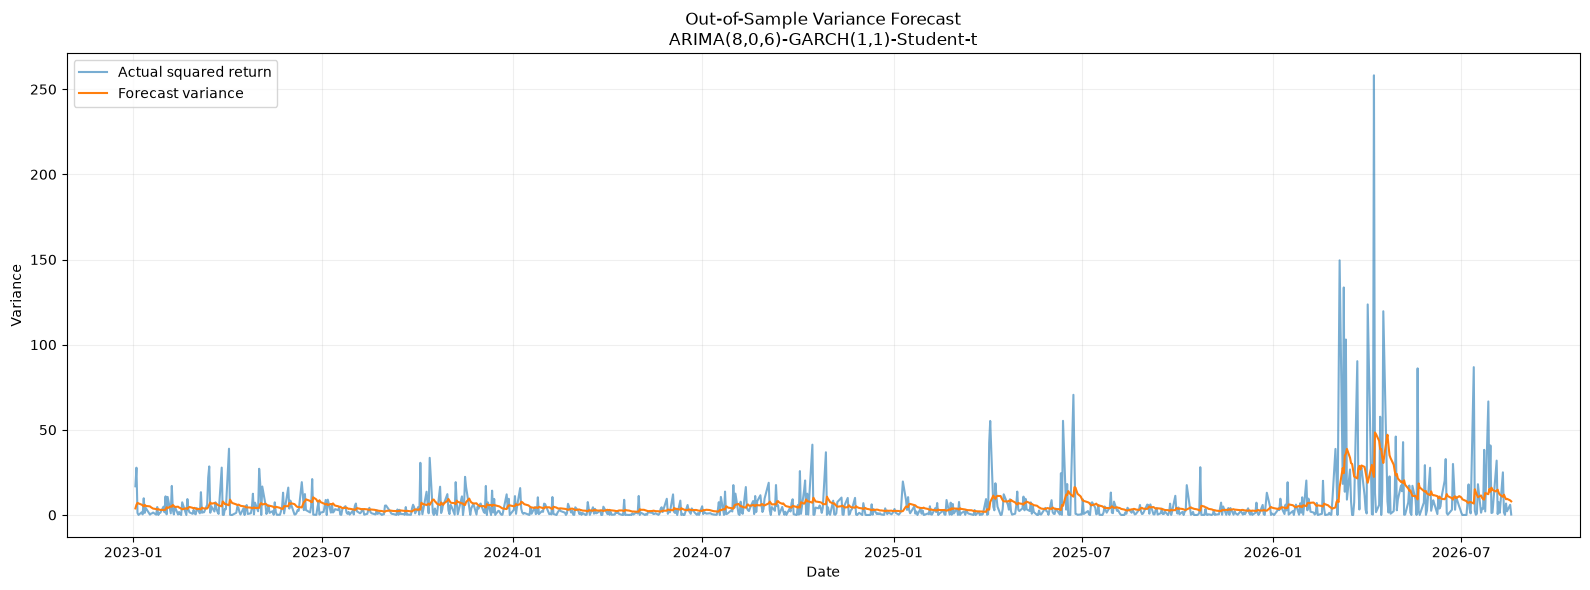

In [172]:
import matplotlib.pyplot as plt

model_name = "ARIMA(8,0,6)-GARCH(1,1)-Student-t"

actual_variance = test_scaled.values ** 2
forecast_variance = forecast_series[model_name]

plt.figure(figsize=(16, 6))

plt.plot(
    test_data.index,
    actual_variance,
    label="Actual squared return",
    alpha=0.6
)

plt.plot(
    test_data.index,
    forecast_variance,
    label="Forecast variance"
)

plt.xlabel("Date")
plt.ylabel("Variance")
plt.title(
    f"Out-of-Sample Variance Forecast\n{model_name}"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

In [173]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ==========================================
# 1. 建立 ARIMA(8,0,6)
# ==========================================

arima_model = ARIMA(
    train_scaled,
    order=(8, 0, 6)
)

arima_result = arima_model.fit()

print(arima_result.summary())

/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood opti

                               SARIMAX Results                                
Dep. Variable:             DCOILWTICO   No. Observations:                 9322
Model:                 ARIMA(8, 0, 6)   Log Likelihood              -26613.733
Date:                Fri, 11 Sep 2026   AIC                          53259.465
Time:                        18:50:42   BIC                          53373.708
Sample:                             0   HQIC                         53298.271
                               - 9322                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0072      0.063      0.113      0.910      -0.117       0.131
ar.L1          0.4582      0.130      3.535      0.000       0.204       0.712
ar.L2         -0.3169      0.066     -4.786      0.0

In [174]:
arima_resid = arima_result.resid
garch_model = arch_model(
    arima_resid,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch_model.fit(disp="off")

print(garch_result.summary())



                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -20701.8
Distribution:      Standardized Student's t   AIC:                           41411.6
Method:                  Maximum Likelihood   BIC:                           41440.2
                                              No. Observations:                 9322
Date:                      Fri, Sep 11 2026   Df Residuals:                     9322
Time:                              18:51:20   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     